<a href="https://colab.research.google.com/github/nodan25/nodan25/blob/main/project_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exploratory Data Analysis (EDA) on the Tips Dataset Using ***Python***

In [7]:
# load a data set
import pandas as pd
df=pd.read_csv("/content/tips.csv")
h=pd.DataFrame(df)
h.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2.0
1,10.34,1.66,Male,No,Sun,Dinner,3.0
2,21.01,3.50,Male,No,Sun,Dinner,3.0
3,23.68,3.31,Male,No,Sun,Dinner,2.0
4,24.59,3.61,Female,No,Sun,Dinner,4.0


In [ ]:
#  information of data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   total_bill  244 non-null    float64
 1   tip         244 non-null    float64
 2   sex         244 non-null    object 
 3   smoker      244 non-null    object 
 4   day         244 non-null    object 
 5   time        244 non-null    object 
 6   size        244 non-null    float64
dtypes: float64(3), object(4)
memory usage: 13.5+ KB


In [11]:
# for mean , min , max , median
df.describe()


,total_bill,tip,size
count,241.000000,242.000000,241.000000
mean,19.743071,2.987521,2.568465
std,8.939602,1.379181,0.951140
min,3.070000,1.000000,1.000000
25%,13.280000,2.000000,2.000000
50%,17.590000,2.855000,2.000000
75%,24.080000,3.540000,3.000000
max,50.810000,10.000000,6.000000


In [12]:
# to find the a value is null or not
df.isnull()

# to get the total number of null
df.isnull().sum()

,0
total_bill,3
tip,2
sex,2
smoker,1
day,1
time,2
size,3


In [13]:
#  for filling the null data
df['total_bill']=df['total_bill'].fillna(df['total_bill'].mean())
df.isnull().sum()

df['day']=df['day'].fillna(df['day'].mode()[0])
df.isnull().sum()

df['tip']=df['tip'].fillna(df['tip'].mean())
df.isnull().sum()

df['smoker']=df['smoker'].fillna(df['smoker'].mode()[0])
df.isnull().sum()

df['time']=df['time'].fillna(df['time'].mode()[0])
df.isnull().sum()

df['size']=df['size'].fillna(df['size'].mean())
df.isnull().sum()

df['sex']=df['sex'].fillna(df['sex'].mode()[0])
df.isnull().sum()

,0
total_bill,0
tip,0
sex,0
smoker,0
day,0
time,0
size,0


In [14]:
#  for finding the duplicate values
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
239,False
240,False
241,False
242,False


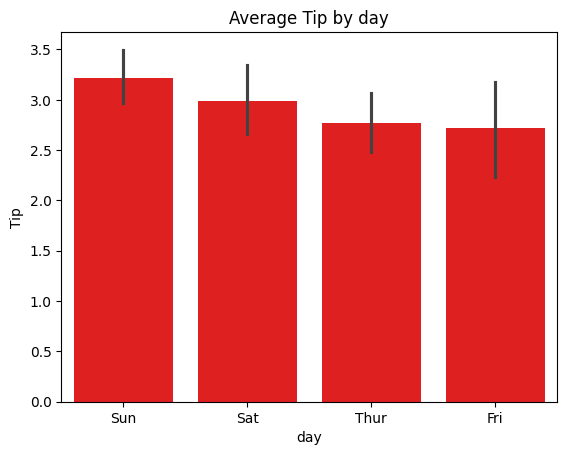

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(x='day', y='tip', data=df , color="red")
plt.title('Average Tip by day') # Add a title for clarity
plt.xlabel('day') # Label the x-axis
plt.ylabel('Tip') # Label the y-axis
plt.show()

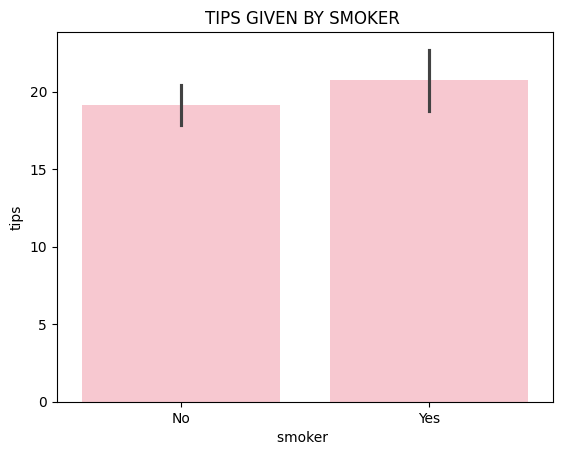

In [17]:
sns.barplot(x='smoker' , y='total_bill',data=df , color='pink')
plt.title('TIPS GIVEN BY SMOKER ')
plt.xlabel('smoker ')
plt.ylabel('tips')

plt.show()

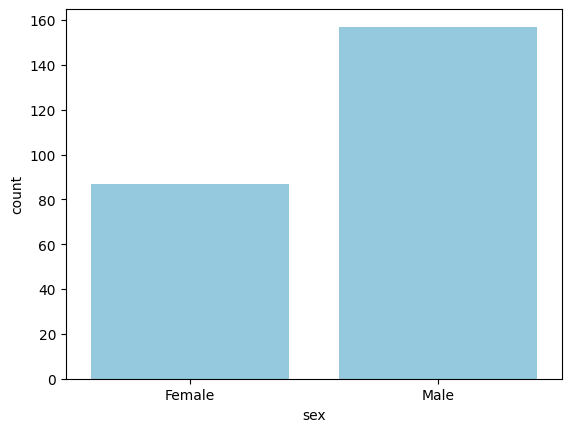

In [ ]:
sns.countplot(x='sex',data=df , color='skyblue')
plt.show()

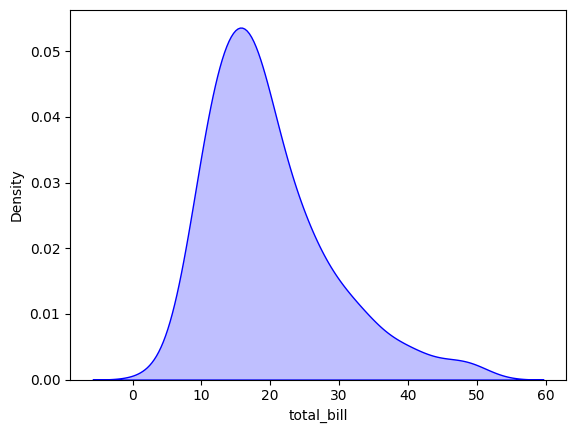

In [ ]:
sns.kdeplot(df["total_bill"] , fill=True , color='blue')

plt.show()

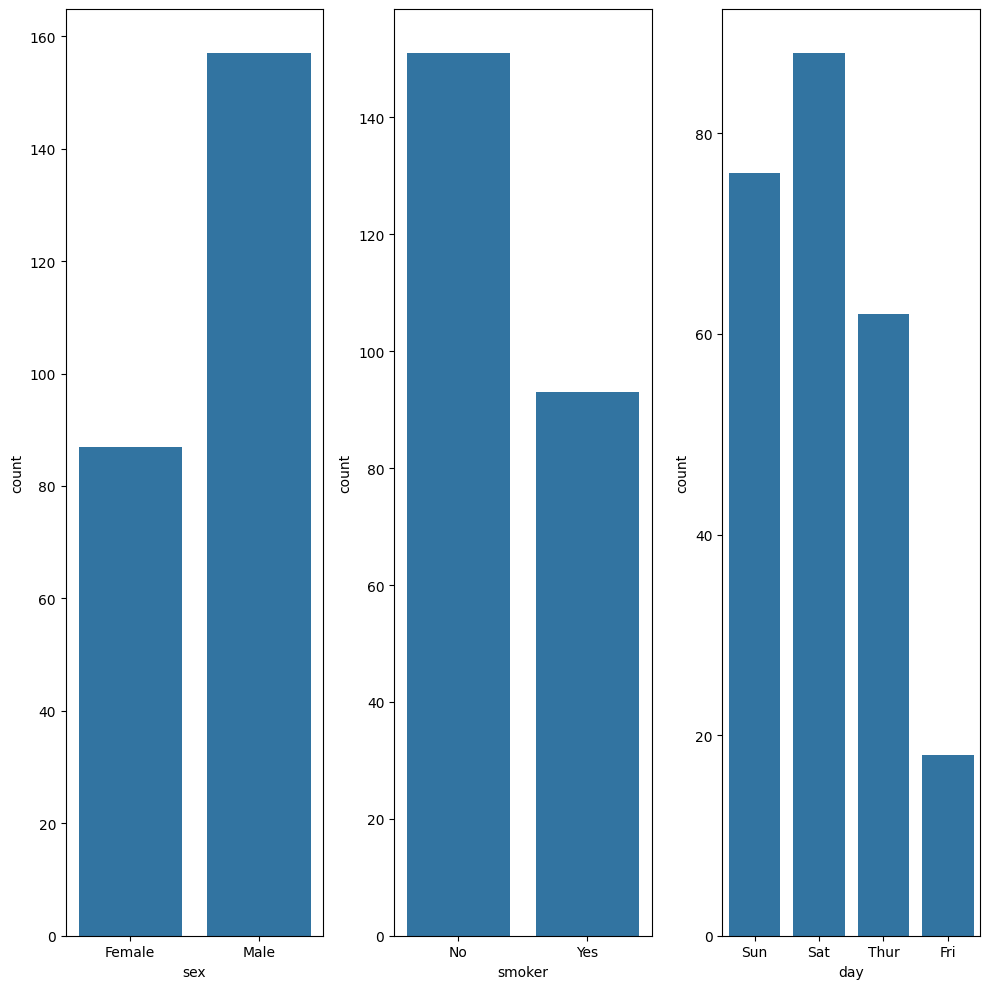

In [ ]:
fig, axes = plt.subplots(1,3 , figsize=(10,10))
sns.countplot(x='sex', data=df , ax=axes[0])
sns.countplot(x='smoker', data=df , ax=axes[1])
sns.countplot(x='day', data=df , ax=axes[2])
plt.tight_layout()
plt.show()

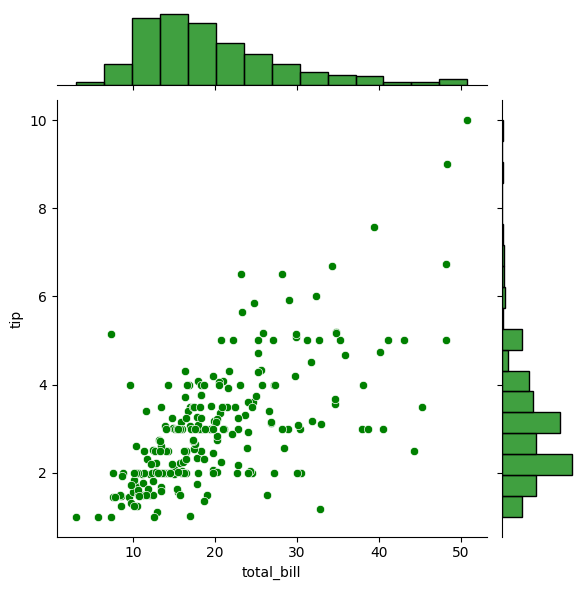

In [ ]:
sns.jointplot(x='total_bill' , y='tip' , data=df , color='green')
plt.show()

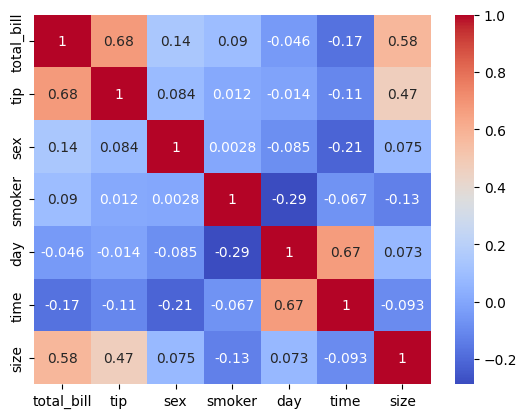

In [ ]:
#  for finding the correlation between them

import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

# Make a copy to avoid modifying the original df if it's used elsewhere
df_encoded = df.copy()

# Apply Label Encoding to categorical columns
le = LabelEncoder()
for column in ['sex', 'smoker', 'day', 'time']:
    df_encoded[column] = le.fit_transform(df_encoded[column])

sns.heatmap(df_encoded.corr(),
            annot=True,
            cmap="coolwarm")

plt.show()